In [1]:
import sqlite3
import pandas as pd 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from math import sqrt 

In [2]:
cnx = sqlite3.connect('../input/database.sqlite')
data = pd.read_sql_query("SELECT * FROM Player_Attributes", cnx)
data.shape

(183978, 42)

In [3]:
data.head()

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,63.0,41.0,45.0,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


Let's get a brief overview of what this data contains. 

In [4]:
data.describe()

,id,player_fifa_api_id,player_api_id,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
count,183978.00000,183978.000000,183978.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,181265.000000,183142.000000,181265.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,181265.000000,183142.000000,181265.000000,183142.000000,181265.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,181265.000000,183142.000000,183142.000000,183142.000000,181265.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000
mean,91989.50000,165671.524291,135900.617324,68.600015,73.460353,55.086883,49.921078,57.266023,62.429672,49.468436,59.175154,52.965675,49.380950,57.069880,63.388879,67.659357,68.051244,65.970910,66.103706,65.189496,61.808427,66.969045,67.038544,67.424529,53.339431,60.948046,52.009271,55.786504,57.873550,55.003986,46.772242,50.351257,48.001462,14.704393,16.063612,20.998362,16.132154,16.441439
std,53110.01825,53851.094769,136927.840510,7.041139,6.592271,17.242135,19.038705,16.488905,14.194068,18.256618,17.744688,18.255788,17.831746,14.394464,15.196671,12.983326,12.569721,12.954585,9.155408,13.063188,16.135143,11.006734,13.165262,12.072280,18.367025,16.089521,19.450133,18.448292,15.144086,15.546519,21.227667,21.483706,21.598778,16.865467,15.867382,21.452980,16.099175,17.198155
min,1.00000,2.000000,2625.000000,33.000000,39.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,2.000000,1.000000,3.000000,5.000000,10.000000,12.000000,11.000000,17.000000,12.000000,2.000000,14.000000,10.000000,10.000000,1.000000,6.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,45995.25000,155798.000000,34763.000000,64.000000,69.000000,45.000000,34.000000,49.000000,57.000000,35.000000,52.000000,41.000000,36.000000,49.000000,58.000000,61.000000,62.000000,58.000000,61.000000,58.000000,54.000000,60.000000,61.000000,60.000000,41.000000,51.000000,34.000000,45.000000,49.000000,45.000000,25.000000,29.000000,25.000000,7.000000,8.000000,8.000000,8.000000,8.000000
50%,91989.50000,183488.000000,77741.000000,69.000000,74.000000,59.000000,53.000000,60.000000,65.000000,52.000000,64.000000,56.000000,50.000000,59.000000,67.000000,69.000000,69.000000,68.000000,67.000000,67.000000,65.000000,68.000000,69.000000,69.000000,58.000000,64.000000,57.000000,60.000000,60.000000,57.000000,50.000000,56.000000,53.000000,10.000000,11.000000,12.000000,11.000000,11.000000
75%,137983.75000,199848.000000,191080.000000,73.000000,78.000000,68.000000,65.000000,68.000000,72.000000,64.000000,72.000000,67.000000,63.000000,67.000000,73.000000,77.000000,77.000000,75.000000,72.000000,74.000000,73.000000,74.000000,76.000000,76.000000,67.000000,73.000000,68.000000,69.000000,69.000000,67.000000,66.000000,69.000000,67.000000,13.000000,15.000000,15.000000,15.000000,15.000000
max,183978.00000,234141.000000,750584.000000,94.000000,97.000000,95.000000,97.000000,98.000000,97.000000,93.000000,97.000000,94.000000,97.000000,97.000000,97.000000,97.000000,97.000000,96.000000,96.000000,96.000000,97.000000,96.000000,96.000000,96.000000,96.000000,97.000000,96.000000,96.000000,97.000000,96.000000,96.000000,95.000000,95.000000,94.000000,93.000000,97.000000,96.000000,96.000000


Let's look at all the columns present in the dataset

In [5]:
data.columns

Index(['id', 'player_fifa_api_id', 'player_api_id', 'date', 'overall_rating',
       'potential', 'preferred_foot', 'attacking_work_rate',
       'defensive_work_rate', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes'],
      dtype='object')

## Data Cleaning 

In [6]:
# Let's look for null values 
data.isnull().sum()
#data[data.isnull().any(axis = 1)]

id                        0
player_fifa_api_id        0
player_api_id             0
date                      0
overall_rating          836
potential               836
preferred_foot          836
attacking_work_rate    3230
defensive_work_rate     836
crossing                836
finishing               836
heading_accuracy        836
short_passing           836
volleys                2713
dribbling               836
curve                  2713
free_kick_accuracy      836
long_passing            836
ball_control            836
acceleration            836
sprint_speed            836
agility                2713
reactions               836
balance                2713
shot_power              836
jumping                2713
stamina                 836
strength                836
long_shots              836
aggression              836
interceptions           836
positioning             836
vision                 2713
penalties               836
marking                 836
standing_tackle     

Let's drop the null values 

In [7]:
data = data.dropna()
data.shape

(180354, 42)

<p style="font-family: Arial; font-size:1.75em;color:blue; font-style:bold"><br>

Declare the Columns You Want to Use as Features
<br><br></p>


In this we can make a dictionay of coorelations of all the features on overall ratings. Let's do that. This is being done to select our features. 

In [8]:
features =list(data.columns[~(data.columns.str.contains('id'))])
features
# We also do not need overall_rating as that is our target and date 
features.remove('date')
features.remove('overall_rating')
features
data[features].head()

,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,71.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,6.0,11.0,10.0,8.0,8.0
1,71.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,6.0,11.0,10.0,8.0,8.0
2,66.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,63.0,41.0,45.0,54.0,48.0,65.0,66.0,6.0,11.0,10.0,8.0,8.0
3,65.0,right,medium,medium,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,5.0,10.0,9.0,7.0,7.0
4,65.0,right,medium,medium,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,5.0,10.0,9.0,7.0,7.0


We can see above that there are more non numeric values in this data. Remove those. 

In [9]:
remove = ['preferred_foot', 'attacking_work_rate', 'defensive_work_rate']
for i in remove:
    features.remove(i)
features

['potential',
 'crossing',
 'finishing',
 'heading_accuracy',
 'short_passing',
 'volleys',
 'dribbling',
 'curve',
 'free_kick_accuracy',
 'long_passing',
 'ball_control',
 'acceleration',
 'sprint_speed',
 'agility',
 'reactions',
 'balance',
 'shot_power',
 'jumping',
 'stamina',
 'strength',
 'long_shots',
 'aggression',
 'interceptions',
 'positioning',
 'vision',
 'penalties',
 'marking',
 'standing_tackle',
 'gk_diving',
 'gk_handling',
 'gk_kicking',
 'gk_positioning',
 'gk_reflexes']

In [10]:
# Let's loop through all the features 

for feature in features:
    co = data['overall_rating'].corr(data[feature])
    dict[feature] = co
dict

TypeError: 'type' object does not support item assignment

Let's also plot these values on line plot to get an idea of the dependence of overall rating on r

### Correlation Plot

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
x_values = []
y_values = []
for value in dict:
    x_values.append(value)
    y_values.append(dict[value])

# Plotting the values using matplotlib.pyplot
plt.xlabel('Features in the data')
plt.ylabel('Correlation Coefficient with Overall Rating')
plt.title('Correlation of Overall Rating with different features')
plt.yticks([0, 1])

#Adjusting the size of the image 
from matplotlib.pyplot import figure
figure(num = None, figsize = (30, 6), dpi=80, facecolor='w', edgecolor='k')

plt.plot(x_values, y_values)
plt.show()


TypeError: 'type' object is not iterable

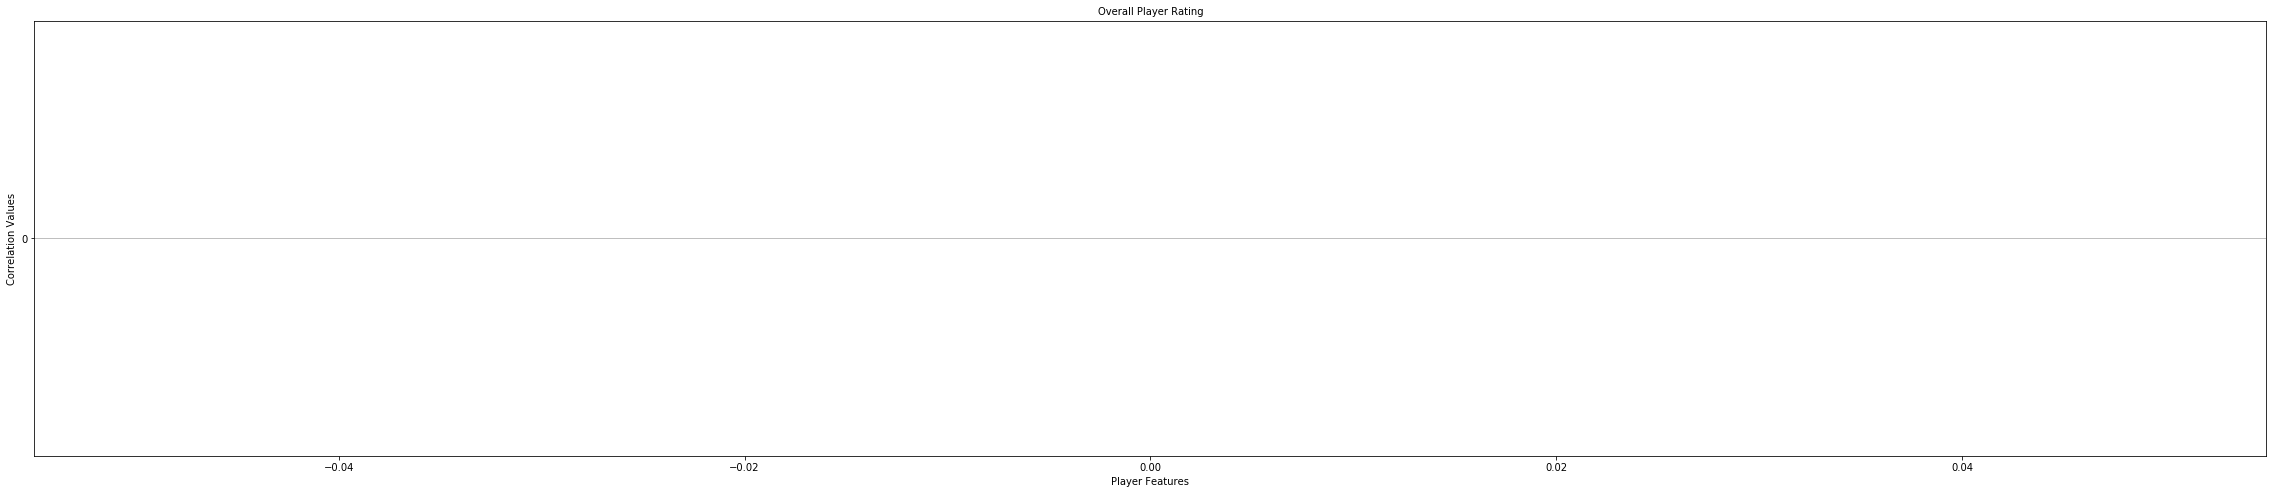

In [12]:
%matplotlib inline

#Plotting a subplot
fig, axis = plt.subplots(figsize = (40, 8))
# Grid lines, Xticks, Xlabel, Ylabel

axis.yaxis.grid(True)
axis.set_title('Overall Player Rating',fontsize=10)
axis.set_xlabel('Player Features',fontsize=10)   
axis.set_ylabel('Correlation Values',fontsize=10)
axis.set_yticks([0,1])
axis.set_yticklabels(['0', '1'])

# # We can also use this to set figure size 
# f.set_figheight(15)
# f.set_figwidth(15)

axis.plot(x_values, y_values)
plt.show()

<p style="font-family: Arial; font-size:1.75em;color:blue; font-style:bold"><br>

Specify the Prediction Target
<br><br></p>


In [13]:
# Let's also specifiy the target 
target = ['overall_rating']

In [14]:
# Obtain the X and y values for regression analysis
X = data[features]
y = data[target]

In [15]:
# Let us look at a typical row from our features:
X.head()
# X.iloc[2]

,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,71.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,6.0,11.0,10.0,8.0,8.0
1,71.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,6.0,11.0,10.0,8.0,8.0
2,66.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,63.0,41.0,45.0,54.0,48.0,65.0,66.0,6.0,11.0,10.0,8.0,8.0
3,65.0,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,5.0,10.0,9.0,7.0,7.0
4,65.0,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,5.0,10.0,9.0,7.0,7.0


Let us also display our target values: 

In [16]:
y.head() 

,overall_rating
0,67.0
1,67.0
2,62.0
3,61.0
4,61.0


<p style="font-family: Arial; font-size:1.75em;color:blue; font-style:bold"><br>

Split the Dataset into Training and Test Datasets
<br><br></p>


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 324)

Feel free to go through the dataset and explore it as much as you can 

In [18]:
X_train.describe()

,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
count,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000,120837.000000
mean,73.470444,55.110529,49.958291,57.270174,62.459263,49.489453,59.242765,52.975968,49.356356,57.047552,63.421493,67.711843,68.121676,65.979187,66.148415,65.167523,61.862451,67.006298,67.041659,67.470204,53.352955,60.933961,51.872299,55.728899,57.849665,54.930899,46.711860,50.302821,14.722039,15.962404,20.525923,16.033475,16.347634
std,6.587725,17.270936,19.061840,16.506733,14.185052,18.264961,17.742900,18.251842,17.821332,14.429803,15.212852,13.013238,12.585959,12.967654,9.139953,13.089994,16.135177,11.012440,13.216776,12.094981,18.388721,16.094201,19.508301,18.473454,15.140026,15.565191,21.248303,21.521759,16.880294,15.857014,21.140388,16.095265,17.218001
min,39.000000,2.000000,1.000000,1.000000,3.000000,1.000000,1.000000,4.000000,1.000000,3.000000,6.000000,10.000000,12.000000,11.000000,17.000000,12.000000,3.000000,14.000000,14.000000,12.000000,1.000000,6.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,69.000000,45.000000,34.000000,49.000000,57.000000,35.000000,52.000000,41.000000,36.000000,49.000000,58.000000,61.000000,62.000000,58.000000,61.000000,58.000000,54.000000,60.000000,61.000000,60.000000,41.000000,51.000000,34.000000,45.000000,49.000000,45.000000,25.000000,29.000000,7.000000,8.000000,8.000000,8.000000,8.000000
50%,74.000000,59.000000,53.000000,60.000000,65.000000,52.000000,64.000000,56.000000,50.000000,59.000000,67.000000,69.000000,69.000000,68.000000,67.000000,67.000000,66.000000,68.000000,69.000000,69.000000,58.000000,64.000000,56.000000,60.000000,60.000000,57.000000,50.000000,56.000000,10.000000,11.000000,12.000000,11.000000,11.000000
75%,78.000000,68.000000,65.000000,68.000000,72.000000,64.000000,72.000000,67.000000,63.000000,67.000000,73.000000,77.000000,77.000000,75.000000,72.000000,74.000000,73.000000,74.000000,76.000000,76.000000,67.000000,73.000000,68.000000,69.000000,69.000000,67.000000,66.000000,69.000000,13.000000,15.000000,15.000000,15.000000,15.000000
max,97.000000,95.000000,97.000000,98.000000,97.000000,93.000000,97.000000,94.000000,97.000000,97.000000,97.000000,97.000000,97.000000,96.000000,96.000000,96.000000,97.000000,96.000000,96.000000,96.000000,96.000000,97.000000,96.000000,95.000000,97.000000,96.000000,94.000000,95.000000,94.000000,93.000000,97.000000,96.000000,96.000000


In [19]:
X_test.describe()

,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
count,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000,59517.000000
mean,73.497757,55.206109,49.969941,57.249878,62.542484,49.487861,59.312432,53.053060,49.466741,57.159753,63.519532,67.704454,68.060924,66.027354,66.148059,65.235882,61.874641,66.918527,67.077238,67.355882,53.457819,60.971101,51.948284,55.734446,57.905758,54.938623,46.849959,50.458104,14.645211,15.918107,20.527076,15.977620,16.279987
std,6.570264,17.198968,19.001086,16.421814,14.146917,18.226779,17.738263,18.232587,17.818009,14.375721,15.136395,13.008319,12.586042,12.955628,9.155349,13.048115,16.118213,11.028617,13.167985,12.064849,18.332506,16.116774,19.432620,18.427399,15.177576,15.539409,21.182739,21.444289,16.762343,15.809431,21.151199,16.020999,17.119227
min,39.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,2.000000,1.000000,4.000000,5.000000,13.000000,13.000000,15.000000,20.000000,15.000000,2.000000,14.000000,10.000000,10.000000,1.000000,8.000000,1.000000,2.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,69.000000,45.000000,34.000000,49.000000,57.000000,36.000000,52.000000,41.000000,36.000000,49.000000,59.000000,61.000000,62.000000,58.000000,61.000000,58.000000,54.000000,60.000000,61.000000,60.000000,41.000000,51.000000,34.000000,45.000000,49.000000,45.000000,25.000000,29.000000,7.000000,8.000000,8.000000,8.000000,8.000000
50%,74.000000,59.000000,53.000000,60.000000,65.000000,52.000000,64.000000,56.000000,51.000000,59.000000,67.000000,69.000000,69.000000,68.000000,67.000000,67.000000,66.000000,68.000000,69.000000,69.000000,58.000000,64.000000,57.000000,60.000000,60.000000,57.000000,51.000000,56.000000,10.000000,11.000000,12.000000,11.000000,11.000000
75%,78.000000,68.000000,65.000000,68.000000,72.000000,64.000000,72.000000,67.000000,64.000000,67.000000,73.000000,77.000000,77.000000,75.000000,72.000000,74.000000,73.000000,74.000000,76.000000,76.000000,67.000000,73.000000,68.000000,69.000000,69.000000,67.000000,66.000000,69.000000,13.000000,15.000000,15.000000,15.000000,15.000000
max,97.000000,95.000000,97.000000,95.000000,97.000000,93.000000,97.000000,94.000000,96.000000,97.000000,96.000000,97.000000,97.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,95.000000,97.000000,96.000000,95.000000,97.000000,96.000000,94.000000,95.000000,94.000000,91.000000,97.000000,94.000000,93.000000


<p style="font-family: Arial; font-size:1.75em;color:blue; font-style:bold"><br>

(1) Linear Regression: Fit a model to the training set
<br><br></p>



In [20]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

<p style="font-family: Arial; font-size:1.75em;color:blue; font-style:bold"><br>

Perform Prediction using Linear Regression Model
<br><br></p>


In [21]:
y_prediction = regressor.predict(X_test)
y_prediction

array([[66.26025486],
       [79.74673933],
       [66.403823  ],
       ...,
       [68.98145792],
       [64.3460468 ],
       [73.59335142]])

In [22]:
#Let's explore the predictions. 
y_prediction.mean()

68.63919405950243

<p style="font-family: Arial; font-size:1.75em;color:blue; font-style:bold"><br>

What is the mean of the expected target value in test set ?
<br><br></p>

In [23]:
y_test.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
overall_rating,59517.0,68.635818,7.041297,33.0,64.0,69.0,73.0,94.0


<p style="font-family: Arial; font-size:1.75em;color:blue; font-style:bold"><br>

Evaluate Linear Regression Accuracy using Root Mean Square Error

<br><br></p>


In [24]:
RMSE = sqrt(mean_squared_error(y_true = y_test, y_pred = y_prediction))

In [25]:
print(RMSE)

2.810620512882101


That is a pretty low error value and that is very good. Let's also find the accuracy and r2 score. 

In [26]:
from sklearn.metrics import r2_score, accuracy_score

In [27]:
print(r2_score(y_test, y_prediction))

0.8406667689726084


In [28]:
#print(accuracy_score(y_test, y_prediction))

## Error
We get an error for the above value. To find out why, [click here](http://https://www.kaggle.com/questions-and-answers/92771****)

<p style="font-family: Arial; font-size:1.75em;color:blue; font-style:bold"><br>

(2) Decision Tree Regressor: Fit a new regression model to the training set
<br><br></p>


In [29]:
decision_regressor = DecisionTreeRegressor(max_depth = 50)
decision_regressor.fit(X_train, y_train)

DecisionTreeRegressor(criterion='mse', max_depth=50, max_features=None,
           max_leaf_nodes=None, min_impurity_decrease=0.0,
           min_impurity_split=None, min_samples_leaf=1,
           min_samples_split=2, min_weight_fraction_leaf=0.0,
           presort=False, random_state=None, splitter='best')

<p style="font-family: Arial; font-size:1.75em;color:blue; font-style:bold"><br>

Perform Prediction using Decision Tree Regressor
<br><br></p>

In [30]:
y_prediction = decision_regressor.predict(X_test)
y_prediction.mean()

68.62024787635706

Let's find out the error value

In [31]:
RMSE = sqrt(mean_squared_error(y_test, y_prediction))
print(RMSE)

1.4151071542110762


We got a surprisingly low error value for this data set compared to Linear Regressor even though the mean of linear regressor was closer to the actual one. We can reduce the error value by increasing the depth of the Decision Tree. We can also increase the accuracy by increasing the size of the training set ( set testsize = 0.1 )